In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torch.optim.lr_scheduler as lr_scheduler
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR, OneCycleLR
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from albumentations import  HorizontalFlip, RandomSizedCrop, Compose, OneOf, Resize
from torchvision.ops import nms
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler, DiffusionPipeline, UNet2DConditionModel
from torchviz import make_dot
from torchinfo import summary
from torch.autograd import Variable
import pandas as pd
from huggingface_hub import snapshot_download
from transformers import CLIPTextModel

import shutil
import re
import gc
import io, json, os, math, sys
import six
import ray
import math
import pickle
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
from glob import glob
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
import subprocess
from PIL import Image, ImageFile, ImageDraw
from IPython.display import display

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [3]:
#inference 및 이미지 합성 함수
#================================================================================
def export_as_gif(filename, images, frames_per_second=10, rubber_band=False):
    if rubber_band:
        images += images[2:-1][::-1]
    images[0].save(
        filename,
        save_all=True,
        append_images=images[1:],
        duration=1000 // frames_per_second,
        loop=0,
    )

# 텍스트 인코딩 함수 (diffusers 파이프라인의 tokenizer, text_encoder 사용)
def get_encoding(prompt):
    inputs = pipe.tokenizer(
        prompt,
        padding="max_length",
        max_length=pipe.tokenizer.model_max_length,
        return_tensors="pt"
    )
    # GPU에 올리기
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        encoding = pipe.text_encoder(**inputs).last_hidden_state  # shape: (1, seq_len, emb_dim)
    return encoding.squeeze(0).to(device)  # shape: (seq_len, emb_dim)

# grid를 만들어 이미지를 저장하는 함수
def plot_grid(images, path, grid_size, scale=2):
    fig = plt.figure(figsize=(grid_size * scale, grid_size * scale))
    fig.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.margins(x=0, y=0)
    for row in range(grid_size):
        for col in range(grid_size):
            index = row * grid_size + col
            ax = plt.subplot(grid_size, grid_size, index + 1)
            ax.imshow(np.array(images[index]))
            ax.axis("off")
            plt.margins(x=0, y=0)
    plt.savefig(fname=path, pad_inches=0, bbox_inches="tight", transparent=False, dpi=60)
    plt.close(fig)

In [4]:
#Hyperparameters
#================================================================================
BATCH_SIZE = 32
LR = 0.0001
EPOCH = 100
PANTIENCE = 6
OPTIMIZER = "Adam"
SCHEDULER="Warmup_cosine"
WARMUP_STEPS=3000
VERBOSE = 10
IMAGE_SHAPE = (256, 256, 3)
HEATMAP_SIZE = (64, 64)
NUM_HEATMAP = 16
NUM_WORKERS = None
RANDOM_SEED = random.randint(0, 1000000000)
PANTIENCE = 10
HOME_DIR = "C:\\Users\\USER"

num_train_shards = 64
num_val_shards = 8

# Image Generation

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


  0%|          | 0/50 [00:00<?, ?it/s]

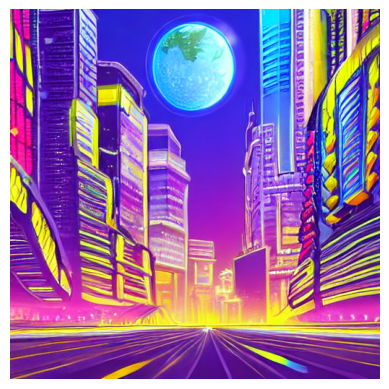

In [5]:
# Pre-trained Stable Diffusion 모델을 불러옵니다.
# 모델 아이디는 원하는 버전(예: "CompVis/stable-diffusion-v1-4" 또는 "runwayml/stable-diffusion-v1-5")에 따라 조정할 수 있습니다.
model_id = "CompVis/stable-diffusion-v1-4"

pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16, requires_safety_checker=False, safety_checker=None)
pipe = pipe.to(device)

# 이제 pipe를 사용하여 텍스트-투-이미지 생성 등을 수행할 수 있습니다.
prompt = "A futuristic cityscape, vibrant and detailed. (not noisy image, clear image, masterpiece, high quality image)"
image = pipe(prompt).images[0]

# 생성된 이미지를 출력합니다.
plt.imshow(np.array(image))
plt.axis("off")
plt.show()

# Text Prompt Interpolation

In [6]:
# 프롬프트와 보간 단계 수 정의
prompt_1 = "A watercolor painting of a Golden Retriever at the beach"
prompt_2 = "A still life DSLR photo of a bowl of fruit"
interpolation_steps = 5

# 토크나이저를 사용해 텍스트를 토큰화합니다.
inputs_1 = pipe.tokenizer(prompt_1, padding="max_length", max_length=pipe.tokenizer.model_max_length, return_tensors="pt")
inputs_2 = pipe.tokenizer(prompt_2, padding="max_length", max_length=pipe.tokenizer.model_max_length, return_tensors="pt")

# CPU에 있는 텐서를 GPU로 이동
inputs_1 = {k: v.to(device) for k, v in inputs_1.items()}
inputs_2 = {k: v.to(device) for k, v in inputs_2.items()}

# 텍스트 인코더를 사용해 프롬프트의 임베딩을 얻습니다.
with torch.no_grad():
    encoding_1 = pipe.text_encoder(**inputs_1).last_hidden_state  # shape: (1, seq_len, emb_dim)
    encoding_2 = pipe.text_encoder(**inputs_2).last_hidden_state

# 배치 차원 제거 (1, seq_len, emb_dim) -> (seq_len, emb_dim)
encoding_1 = encoding_1.squeeze(0)
encoding_2 = encoding_2.squeeze(0)

# 두 인코딩 사이를 선형 보간합니다.
alphas = torch.linspace(0, 1, steps=interpolation_steps, device=encoding_1.device)
# 각 보간 단계마다 encoding_1과 encoding_2의 가중 평균을 계산합니다.
interpolated_encodings = [(1 - alpha) * encoding_1 + alpha * encoding_2 for alpha in alphas]
# 보간 결과를 하나의 텐서로 스택 (shape: (interpolation_steps, seq_len, emb_dim))
interpolated_encodings = torch.stack(interpolated_encodings).to(torch.float16)

# 임베딩의 shape 출력
print(f"Encoding shape: {encoding_1.shape}")

Encoding shape: torch.Size([77, 768])


In [7]:
# 시드 설정 및 생성기 초기화
generator = torch.Generator(device=device).manual_seed(RANDOM_SEED)

# latent 공간 크기: (batch_size, 4, height, width)
latent_height = 512 // 8  # 64
latent_width = 512 // 8   # 64

# interpolation_steps 만큼의 노이즈(초기 잠재 변수)를 생성
latents = torch.randn(
    (interpolation_steps, 4, latent_height, latent_width),
    generator=generator,
    dtype=torch.float16,
    device=device
)

# 파이프라인 호출: prompt_embeds에 보간된 텍스트 임베딩을,
# latents에 미리 생성한 노이즈를 전달합니다.
images = pipe(
    prompt_embeds=interpolated_encodings,
    latents=latents,
    generator=generator
).images

  0%|          | 0/50 [00:00<?, ?it/s]

In [8]:
# 프롬프트 정의/ safety_checker 있음, prompt에서 낮은 화질의 이미지 허용
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16, requires_safety_checker=False)
pipe = pipe.to(device)

prompt_1 = "A watercolor painting of a Golden Retriever at the beach"
prompt_2 = "A still life DSLR photo of a bowl of fruit"
prompt_3 = "The eiffel tower in the style of starry night"
prompt_4 = "An architectural sketch of a skyscraper"

# 보간 관련 설정
interpolation_steps = 16
batch_size = 3
# 총 생성할 임베딩 수: 6 * 6 = 36, 배치 수 = 36 // 3 = 12
batches = (interpolation_steps**2) // batch_size

# 텍스트 인코딩 함수 (diffusers 파이프라인의 tokenizer, text_encoder 사용)
def get_encoding(prompt):
    inputs = pipe.tokenizer(
        prompt,
        padding="max_length",
        max_length=pipe.tokenizer.model_max_length,
        return_tensors="pt"
    )
    # GPU에 올리기
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        encoding = pipe.text_encoder(**inputs).last_hidden_state  # shape: (1, seq_len, emb_dim)
    return encoding.squeeze(0).to(device)  # shape: (seq_len, emb_dim)

# 각 프롬프트에 대한 인코딩을 GPU로 가져옵니다.
encoding_1 = get_encoding(prompt_1)
encoding_2 = get_encoding(prompt_2)
encoding_3 = get_encoding(prompt_3)
encoding_4 = get_encoding(prompt_4)

# 1차 보간: encoding_1 ~ encoding_2, encoding_3 ~ encoding_4
alphas = torch.linspace(0, 1, interpolation_steps, device=device)
lin1 = torch.stack([ (1 - alpha) * encoding_1 + alpha * encoding_2 for alpha in alphas ])
lin2 = torch.stack([ (1 - alpha) * encoding_3 + alpha * encoding_4 for alpha in alphas ])

# 2차 보간: lin1 ~ lin2 (결과 shape: (interpolation_steps, interpolation_steps, seq_len, emb_dim))
betas = torch.linspace(0, 1, interpolation_steps, device=device)
interpolated_encodings = torch.stack([ (1 - beta) * lin1 + beta * lin2 for beta in betas ])

# reshape to (interpolation_steps**2, seq_len, emb_dim) => (36, 77, 768)
interpolated_encodings = interpolated_encodings.view(interpolation_steps**2, *lin1.shape[1:])
# 보간된 임베딩을 GPU로 확실히 옮깁니다.
interpolated_encodings = interpolated_encodings.to(device)

# 배치별로 분할 (각 배치에 batch_size개씩)
batched_encodings = torch.split(interpolated_encodings, batch_size)

# 이미지 생성을 위한 latent 공간의 크기 (일반적으로 512/8 = 64)
latent_height = 512 // 8  # 64
latent_width = 512 // 8   # 64

images = []
# 각 배치마다 노이즈(초기 잠재 변수)를 생성하고 파이프라인 호출
for batch in batched_encodings:
    current_batch_size = batch.shape[0]
    # latents를 생성할 때도 device, dtype 등이 올바른지 확인합니다.
    latents = torch.randn(
        (current_batch_size, 4, latent_height, latent_width),
        generator=generator,
        dtype=torch.float16,
        device=device
    )
    # 배치의 텍스트 임베딩도 GPU에 있는지 확인 (to(device) 호출)
    batch = batch.to(device)
    output = pipe(
        prompt_embeds=batch,
        latents=latents,
        num_inference_steps=50,
        generator=generator
    )
    images.extend(output.images)  # output.images: PIL 이미지 객체 리스트

# grid_size는 interpolation_steps (6)
plot_grid(images, "img/4-way-interpolation_without_safety_checker_allow_low_quality.jpg", interpolation_steps)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/50 [00:00<?, ?it/s]

...

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [9]:
# 프롬프트 정의/ safety_checker 있음
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16, requires_safety_checker=False)
pipe = pipe.to(device)

prompt_1 = "A watercolor painting of a Golden Retriever at the beach. (not noisy image, clear image, masterpiece, high quality image)"
prompt_2 = "A still life DSLR photo of a bowl of fruit. (not noisy image, clear image, masterpiece, high quality image)"
prompt_3 = "The eiffel tower in the style of starry night. (not noisy image, clear image, masterpiece, high quality image)"
prompt_4 = "An architectural sketch of a skyscraper. (not noisy image, clear image, masterpiece, high quality image)"

# 보간 관련 설정
interpolation_steps = 16
batch_size = 3
# 총 생성할 임베딩 수: 6 * 6 = 36, 배치 수 = 36 // 3 = 12
batches = (interpolation_steps**2) // batch_size

# 텍스트 인코딩 함수 (diffusers 파이프라인의 tokenizer, text_encoder 사용)
def get_encoding(prompt):
    inputs = pipe.tokenizer(
        prompt,
        padding="max_length",
        max_length=pipe.tokenizer.model_max_length,
        return_tensors="pt"
    )
    # GPU에 올리기
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        encoding = pipe.text_encoder(**inputs).last_hidden_state  # shape: (1, seq_len, emb_dim)
    return encoding.squeeze(0).to(device)  # shape: (seq_len, emb_dim)

# 각 프롬프트에 대한 인코딩을 GPU로 가져옵니다.
encoding_1 = get_encoding(prompt_1)
encoding_2 = get_encoding(prompt_2)
encoding_3 = get_encoding(prompt_3)
encoding_4 = get_encoding(prompt_4)

# 1차 보간: encoding_1 ~ encoding_2, encoding_3 ~ encoding_4
alphas = torch.linspace(0, 1, interpolation_steps, device=device)
lin1 = torch.stack([ (1 - alpha) * encoding_1 + alpha * encoding_2 for alpha in alphas ])
lin2 = torch.stack([ (1 - alpha) * encoding_3 + alpha * encoding_4 for alpha in alphas ])

# 2차 보간: lin1 ~ lin2 (결과 shape: (interpolation_steps, interpolation_steps, seq_len, emb_dim))
betas = torch.linspace(0, 1, interpolation_steps, device=device)
interpolated_encodings = torch.stack([ (1 - beta) * lin1 + beta * lin2 for beta in betas ])

# reshape to (interpolation_steps**2, seq_len, emb_dim) => (36, 77, 768)
interpolated_encodings = interpolated_encodings.view(interpolation_steps**2, *lin1.shape[1:])
# 보간된 임베딩을 GPU로 확실히 옮깁니다.
interpolated_encodings = interpolated_encodings.to(device)

# 배치별로 분할 (각 배치에 batch_size개씩)
batched_encodings = torch.split(interpolated_encodings, batch_size)

# 이미지 생성을 위한 latent 공간의 크기 (일반적으로 512/8 = 64)
latent_height = 512 // 8  # 64
latent_width = 512 // 8   # 64

images = []
# 각 배치마다 노이즈(초기 잠재 변수)를 생성하고 파이프라인 호출
for batch in batched_encodings:
    current_batch_size = batch.shape[0]
    # latents를 생성할 때도 device, dtype 등이 올바른지 확인합니다.
    latents = torch.randn(
        (current_batch_size, 4, latent_height, latent_width),
        generator=generator,
        dtype=torch.float16,
        device=device
    )
    # 배치의 텍스트 임베딩도 GPU에 있는지 확인 (to(device) 호출)
    batch = batch.to(device)
    output = pipe(
        prompt_embeds=batch,
        latents=latents,
        num_inference_steps=50,
        generator=generator
    )
    images.extend(output.images)  # output.images: PIL 이미지 객체 리스트

# grid_size는 interpolation_steps (16)
plot_grid(images, "img/4-way-interpolation_with_safety_checker.jpg", interpolation_steps)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [10]:
# 프롬프트 정의
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16, requires_safety_checker=False, safety_checker=None)
pipe = pipe.to(device)

prompt_1 = "A watercolor painting of a Golden Retriever at the beach. (not noisy image, clear image, masterpiece, high quality image)"
prompt_2 = "A still life DSLR photo of a bowl of fruit. (not noisy image, clear image, masterpiece, high quality image)"
prompt_3 = "The eiffel tower in the style of starry night. (not noisy image, clear image, masterpiece, high quality image)"
prompt_4 = "An architectural sketch of a skyscraper. (not noisy image, clear image, masterpiece, high quality image)"

# 보간 관련 설정
interpolation_steps = 16
batch_size = 4
# 총 생성할 임베딩 수: 6 * 6 = 36, 배치 수 = 36 // 3 = 12
batches = (interpolation_steps**2) // batch_size

# 텍스트 인코딩 함수 (diffusers 파이프라인의 tokenizer, text_encoder 사용)
def get_encoding(prompt):
    inputs = pipe.tokenizer(
        prompt,
        padding="max_length",
        max_length=pipe.tokenizer.model_max_length,
        return_tensors="pt"
    )
    # GPU에 올리기
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        encoding = pipe.text_encoder(**inputs).last_hidden_state  # shape: (1, seq_len, emb_dim)
    return encoding.squeeze(0).to(device)  # shape: (seq_len, emb_dim)

# 각 프롬프트에 대한 인코딩을 GPU로 가져옵니다.
encoding_1 = get_encoding(prompt_1)
encoding_2 = get_encoding(prompt_2)
encoding_3 = get_encoding(prompt_3)
encoding_4 = get_encoding(prompt_4)

# 1차 보간: encoding_1 ~ encoding_2, encoding_3 ~ encoding_4
alphas = torch.linspace(0, 1, interpolation_steps, device=device)
lin1 = torch.stack([ (1 - alpha) * encoding_1 + alpha * encoding_2 for alpha in alphas ])
lin2 = torch.stack([ (1 - alpha) * encoding_3 + alpha * encoding_4 for alpha in alphas ])

# 2차 보간: lin1 ~ lin2 (결과 shape: (interpolation_steps, interpolation_steps, seq_len, emb_dim))
betas = torch.linspace(0, 1, interpolation_steps, device=device)
interpolated_encodings = torch.stack([ (1 - beta) * lin1 + beta * lin2 for beta in betas ])

# reshape to (interpolation_steps**2, seq_len, emb_dim) => (36, 77, 768)
interpolated_encodings = interpolated_encodings.view(interpolation_steps**2, *lin1.shape[1:])
# 보간된 임베딩을 GPU로 확실히 옮깁니다.
interpolated_encodings = interpolated_encodings.to(device)

# 배치별로 분할 (각 배치에 batch_size개씩)
batched_encodings = torch.split(interpolated_encodings, batch_size)

# 이미지 생성을 위한 latent 공간의 크기 (일반적으로 512/8 = 64)
latent_height = 512 // 8  # 64
latent_width = 512 // 8   # 64

images = []
# 각 배치마다 노이즈(초기 잠재 변수)를 생성하고 파이프라인 호출
for batch in batched_encodings:
    current_batch_size = batch.shape[0]
    # latents를 생성할 때도 device, dtype 등이 올바른지 확인합니다.
    latents = torch.randn(
        (current_batch_size, 4, latent_height, latent_width),
        generator=generator,
        dtype=torch.float16,
        device=device
    )
    # 배치의 텍스트 임베딩도 GPU에 있는지 확인 (to(device) 호출)
    batch = batch.to(device)
    output = pipe(
        prompt_embeds=batch,
        latents=latents,
        num_inference_steps=50,
        generator=generator
    )
    images.extend(output.images)  # output.images: PIL 이미지 객체 리스트

# grid_size는 interpolation_steps (6)
plot_grid(images, "img/4-way-interpolation.jpg", interpolation_steps)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [12]:
images = []
for batch in range(batches):
    batch_encodings = batched_encodings[batch]  # shape: (batch_size, seq_len, emb_dim)
    current_batch_size = batch_encodings.shape[0]
    # 각 배치마다 새로운 노이즈(잠재 변수)를 생성합니다.
    latents = torch.randn(
        (current_batch_size, 4, latent_height, latent_width),
        generator=generator,
        dtype=torch.float16,
        device=device
    )
    # 파이프라인 호출: 텍스트 임베딩(prompt_embeds)와 노이즈(latents)를 전달합니다.
    output = pipe(
        prompt_embeds=batch_encodings,
        latents=latents,
        num_inference_steps=50,
        generator=generator
    )
    images.extend(output.images)  # output.images는 PIL 이미지 객체 리스트

# plot_grid 함수는 PIL 이미지 리스트를 받아 grid로 저장합니다.
plot_grid(images, "img/4-way-interpolation-varying-noise.jpg", interpolation_steps)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [13]:
walk_steps = 150
batch_size = 3
batches = walk_steps // batch_size  # 예: 150 / 3 = 50
step_size = 0.005

# "The Eiffel Tower in the style of starry night" 프롬프트에 대한 텍스트 인코딩 얻기
# get_encoding 함수는 이전에 정의된 함수로, 프롬프트를 토큰화하고 텍스트 인코딩을 반환합니다.
encoding = get_encoding("The Eiffel Tower in the style of starry night. (not noisy image, clear image, masterpiece, high quality image)")  # shape: (77, 768)

# 각 스텝마다 더할 변화량(delta) 생성
delta = torch.ones_like(encoding) * step_size

# 워크 스텝에 따른 인코딩 리스트 생성 (각 스텝마다 인코딩에 delta를 더함)
walked_encodings = []
for step_index in range(walk_steps):
    # clone()을 사용하여 현재 encoding의 복사본을 저장 (참조가 누적되지 않도록)
    walked_encodings.append(encoding.clone())
    encoding = encoding + delta

# walked_encodings의 shape: (walk_steps, 77, 768)
walked_encodings = torch.stack(walked_encodings)
# 배치 크기(batch_size)로 분할: 총 (150 / 3) = 50개의 배치 생성
batched_encodings = torch.split(walked_encodings, batch_size)

# 이미지 생성
images = []
for batch in batched_encodings:
    current_batch_size = batch.shape[0]
    # 잠재(latent) 공간 크기: (batch_size, 4, latent_height, latent_width)
    latents = torch.randn(
        (current_batch_size, 4, latent_height, latent_width),
        generator=generator,
        dtype=torch.float16,
        device=device
    )
    # 파이프라인 호출: 텍스트 임베딩(prompt_embeds)와 초기 잠재(latents)를 사용하여 이미지를 생성
    output = pipe(
        prompt_embeds=batch,
        latents=latents,
        num_inference_steps=50,
        generator=generator
    )
    images.extend(output.images)  # output.images는 PIL 이미지 객체 리스트

# GIF로 내보내기 (export_as_gif 함수는 이전에 정의된 함수)
export_as_gif("img/eiffel-tower-starry-night.gif", images, rubber_band=True)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [14]:
# 전제: device, generator, pipe, export_as_gif, get_encoding 함수는 이미 정의되어 있다고 가정합니다.
# 예: device = "cuda" if torch.cuda.is_available() else "cpu"

prompt = "An oil paintings of detailed cows in a field next to a windmill in Holland. (not noisy image, clear image, masterpiece, high quality image)"
# get_encoding 함수는 이전에 정의한 텍스트 인코딩 함수 (출력 shape: (seq_len, emb_dim))
encoding = get_encoding(prompt)  # shape: (77, 768)

walk_steps = 150
batch_size = 3
batches = walk_steps // batch_size  # 150/3 = 50

# 잠재(latent) 공간 크기 설정 (일반적으로 512/8 = 64)
latent_channels = 4
latent_height = 512 // 8  # 64
latent_width = 512 // 8   # 64

# base noise shape: (4, 64, 64)
base_noise_shape = (latent_channels, latent_height, latent_width)

# 두 방향의 난수 노이즈 (dtype는 torch.float64로 생성 후, 나중에 float16로 변환)
walk_noise_x = torch.randn(base_noise_shape, dtype=torch.float64, device=device)
walk_noise_y = torch.randn(base_noise_shape, dtype=torch.float64, device=device)

# walk 스케일 계산: 0~2 사이를 interpolation, 각각 코사인과 사인 적용 (결과 shape: (walk_steps,))
walk_scale_x = torch.cos(torch.linspace(0, 2, walk_steps, device=device) * math.pi)
walk_scale_y = torch.sin(torch.linspace(0, 2, walk_steps, device=device) * math.pi)

# tensordot 대신 broadcasting을 사용: 각 스케일에 대해 base noise 곱하기
# 결과 noise_x, noise_y shape: (walk_steps, 4, 64, 64)
noise_x = walk_scale_x.view(walk_steps, 1, 1, 1) * walk_noise_x
noise_y = walk_scale_y.view(walk_steps, 1, 1, 1) * walk_noise_y

# 최종 노이즈: (walk_steps, 4, 64, 64)
noise = noise_x + noise_y
noise = noise.to(torch.float16)

# 배치 단위로 분할: batched_noise는 길이 batches인 튜플, 각 요소 shape: (batch_size, 4, 64, 64)
batched_noise = torch.split(noise, batch_size, dim=0)

# 이미지 생성
images = []
# 텍스트 인코딩은 shape (77, 768); 배치 처리를 위해 unsqueeze 후 expand하여 (batch_size, 77, 768)로 만듭니다.
encoding_expanded = encoding.unsqueeze(0).to(torch.float16)  # shape: (1, 77, 768)

for batch_noise in batched_noise:
    current_batch_size = batch_noise.shape[0]  # 보통 batch_size와 같음
    prompt_embeds = encoding_expanded.expand(current_batch_size, -1, -1)

    # 파이프라인 호출: prompt_embeds와 해당 배치의 latents를 전달합니다.
    output = pipe(
        prompt_embeds=prompt_embeds,
        latents=batch_noise,
        num_inference_steps=50,
        generator=generator
    )
    # output.images는 PIL 이미지 객체 리스트
    images.extend(output.images)

# GIF로 저장 (export_as_gif 함수는 이전에 정의되어 있다고 가정)
export_as_gif("img/cows.gif", images)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

# DreamBooth

In [15]:
local_dir = os.path.join(HOME_DIR, "diffusers_git/examples/dreambooth/dog")
snapshot_download(
    "diffusers/dog-example",
    local_dir=local_dir, repo_type="dataset",
    ignore_patterns=".gitattributes",
)
print(local_dir)

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

C:\Users\USER\diffusers_git/examples/dreambooth/dog


In [16]:
%reset -f
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torch.optim.lr_scheduler as lr_scheduler
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR, OneCycleLR
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from albumentations import  HorizontalFlip, RandomSizedCrop, Compose, OneOf, Resize
from torchvision.ops import nms
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler, DiffusionPipeline, UNet2DConditionModel
from torchviz import make_dot
from torchinfo import summary
from torch.autograd import Variable
import pandas as pd
from huggingface_hub import snapshot_download
from transformers import CLIPTextModel

import shutil
import re
import gc
import io, json, os, math, sys
import six
import ray
import math
import pickle
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
from glob import glob
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
import subprocess
from PIL import Image, ImageFile, ImageDraw
from IPython.display import display

In [17]:
#Hyperparameters
#================================================================================
BATCH_SIZE = 32
LR = 0.0001
EPOCH = 100
PANTIENCE = 6
OPTIMIZER = "Adam"
SCHEDULER="Warmup_cosine"
WARMUP_STEPS=3000
VERBOSE = 10
IMAGE_SHAPE = (256, 256, 3)
HEATMAP_SIZE = (64, 64)
NUM_HEATMAP = 16
NUM_WORKERS = None
RANDOM_SEED = random.randint(0, 1000000000)
PANTIENCE = 10
HOME_DIR = "C:\\Users\\USER"
DATA_PATH = "E:\AIFFEL\Data\.huggingface"
LORA_PATH_1 = "E:\AIFFEL\Data\.huggingface\collage-art-style-v03.safetensors"
LORA_PATH_2 = "E:\AIFFEL\Data\.huggingface\pollock-01.safetensors"
LORA_PATH_3 = "E:\AIFFEL\Data\.huggingface\Char - Blue Archive - Sukeban (MG) v2.safetensors"

num_train_shards = 64
num_val_shards = 8

In [18]:
# 약 10분 정도 소요됩니다.
! rmdir /S /Q -rf C:\Users\USER\diffusers_git\examples\dreambooth\dog\.cache

# 1) 경로 설정
BASE_DIR = "C:/Users/USER/diffusers_git/examples/dreambooth"

MODEL_NAME   = "CompVis/stable-diffusion-v1-4"
INSTANCE_DIR = os.path.join(BASE_DIR, "dog")
CLASS_DIR    = os.path.join(BASE_DIR, "dog")
OUTPUT_DIR   = os.path.join(BASE_DIR, "data")

print("MODEL_NAME:", MODEL_NAME)
print("INSTANCE_DIR:", INSTANCE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

# 2) accelerate

cmd = [
    sys.executable,
    "-m", "accelerate.commands.launch",
    os.path.join(BASE_DIR, "train_dreambooth.py"),

    f"--pretrained_model_name_or_path={MODEL_NAME}",
    f"--instance_data_dir={INSTANCE_DIR}",
    f"--class_data_dir={CLASS_DIR}",
    f"--output_dir={OUTPUT_DIR}",
    "--instance_prompt=a photo of sks dog",
    "--class_prompt=a photo of dog",
    "--resolution=512",
    "--train_batch_size=1",
    "--with_prior_preservation",
    "--prior_loss_weight=1.0",
    "--gradient_accumulation_steps=1",
    "--gradient_checkpointing",
    "--use_8bit_adam",
    "--set_grads_to_none",
    "--learning_rate=2e-6",
    "--lr_scheduler=constant",
    "--lr_warmup_steps=0",
    "--num_class_images=5",
    "--max_train_steps=100",
]

subprocess.run(cmd, capture_output=True, text=True)

print('----'*64)
print('학습 완료!!')

지정된 파일을 찾을 수 없습니다.


MODEL_NAME: CompVis/stable-diffusion-v1-4
INSTANCE_DIR: C:/Users/USER/diffusers_git/examples/dreambooth\dog
OUTPUT_DIR: C:/Users/USER/diffusers_git/examples/dreambooth\data
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
학습 완료!!


In [19]:
# 초기화 후 재 import
%reset -f
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torch.optim.lr_scheduler as lr_scheduler
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR, OneCycleLR
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from albumentations import  HorizontalFlip, RandomSizedCrop, Compose, OneOf, Resize
from torchvision.ops import nms
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler, DiffusionPipeline, UNet2DConditionModel
from torchviz import make_dot
from torchinfo import summary
from torch.autograd import Variable
import pandas as pd
from huggingface_hub import snapshot_download
from transformers import CLIPTextModel

import shutil
import re
import gc
import io, json, os, math, sys
import six
import ray
import math
import pickle
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
from glob import glob
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
import subprocess
from PIL import Image, ImageFile, ImageDraw
from IPython.display import display

In [20]:
#Hyperparameters
#================================================================================
BATCH_SIZE = 32
LR = 0.0001
EPOCH = 100
PANTIENCE = 6
OPTIMIZER = "Adam"
SCHEDULER="Warmup_cosine"
WARMUP_STEPS=3000
VERBOSE = 10
IMAGE_SHAPE = (256, 256, 3)
HEATMAP_SIZE = (64, 64)
NUM_HEATMAP = 16
NUM_WORKERS = None
RANDOM_SEED = random.randint(0, 1000000000)
PANTIENCE = 10
HOME_DIR = "C:\\Users\\USER"
LORA_PATH_1 = "E:\AIFFEL\Data\.huggingface\collage-art-style-v03.safetensors"
LORA_PATH_2 = "E:\AIFFEL\Data\.huggingface\pollock-01.safetensors"
LORA_PATH_3 = "E:\AIFFEL\Data\.huggingface\Char - Blue Archive - Sukeban (MG) v2.safetensors"

In [21]:
# # 의존성 모듈을 삭제 후 다시 설치합니다.
!pip uninstall -y diffusers
!pip install diffusers

# huggingface에 미리 등록된 base 모델을 다운로드하여 사용합니다.
model_id = "CompVis/stable-diffusion-v1-4"

unet_path = os.path.join(HOME_DIR,"diffusers_git/examples/dreambooth/data/unet")
text_encoder_path = os.path.join(HOME_DIR,"diffusers_git/examples/dreambooth/data/text_encoder")

# 앞서 학습 코드로 만들어진 파라미터들을 로드합니다.
unet = UNet2DConditionModel.from_pretrained(unet_path)
text_encoder = CLIPTextModel.from_pretrained(text_encoder_path)

# stable diffusion 의 전체 파이프라인을 구성해줍니다.
pipeline = DiffusionPipeline.from_pretrained(model_id, unet=unet, text_encoder=text_encoder)
pipeline.to("cuda")

Found existing installation: diffusers 0.35.2
Uninstalling diffusers-0.35.2:
  Successfully uninstalled diffusers-0.35.2
  Using cached diffusers-0.35.2-py3-none-any.whl.metadata (20 kB)
Using cached diffusers-0.35.2-py3-none-any.whl (4.1 MB)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.36.0.dev0",
  "_name_or_path": "CompVis/stable-diffusion-v1-4",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

  0%|          | 0/100 [00:00<?, ?it/s]

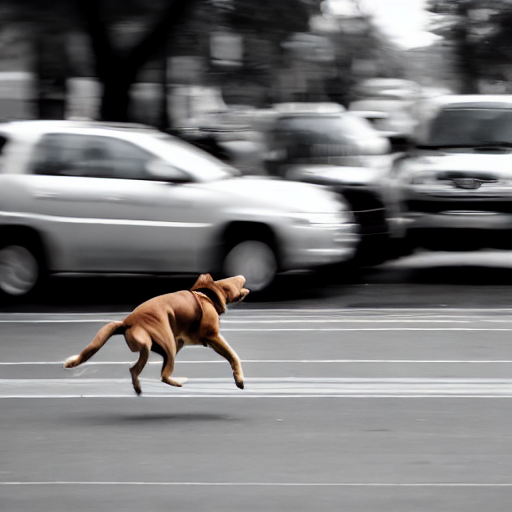

In [22]:
prompt = "A photo of sks dog chasing a car. (not noisy image, clear image, masterpiece, high quality image)"
image = pipeline(prompt, num_inference_steps=100, guidance_scale=7.5).images[0]

image.save("img/dog-bucket.png")
image

# LoRA

In [23]:
pipeline = StableDiffusionPipeline.from_pretrained("digiplay/hellofantasytime_v1.22", torch_dtype=torch.float16, requires_safety_checker=False, safety_checker=None)   # 알맞은 모델 ID 를 입력합니다.
pipeline.scheduler = DPMSolverMultistepScheduler.from_config(pipeline.scheduler.config)
pipeline.to("cuda")

pipeline.load_lora_weights(LORA_PATH_1)   # 다운로드한 LoRA 를 로드합니다.

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.


In [24]:
image = pipeline(
    prompt="masterpiece, best quality, high quality, collage,<lora:collage-art-style-v03>,rainbow,",
    negative_prompt="(((pubic))), ((((pubic_hair)))),sketch, duplicate, ugly,text, logo, monochrome, (worst quality:2.0), (low quality:2.0), (blurry:2.0), horror, geometry, (bad hands), (missing fingers), multiple limbs, bad anatomy, (interlocked fingers:1.2), Ugly Fingers, (extra digit and hands and fingers and legs and arms:1.4), (deformed fingers:1.2), (long fingers:1.2)",
    num_inference_steps=100,
    guidance_scale=7,
    cross_attention_kwargs={"scale": 0.95}
).images[0]

os.makedirs("img", exist_ok=True) 
image.save("img/sd_lora_sample_1.png")

  0%|          | 0/100 [00:00<?, ?it/s]

<img src="/GoingDeeper/GoingDeeper09/img/sd_lora_sample_1.png" width="768px" height="768px"></img>

In [25]:
pipeline = StableDiffusionPipeline.from_pretrained("digiplay/hellofantasytime_v1.22", torch_dtype=torch.float16, requires_safety_checker=False, safety_checker=None)   # 알맞은 모델 ID 를 입력합니다.
pipeline.scheduler = DPMSolverMultistepScheduler.from_config(pipeline.scheduler.config)
pipeline.to("cuda")

pipeline.load_lora_weights(LORA_PATH_2)   # 다운로드한 LoRA 를 로드합니다.

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.


In [26]:
image = pipeline(
    prompt="masterpiece, clear image, best quality, high quality, ultradetailed, drawing of a beautiful girl, ((ultradetailed eye)), p0ll0ck, colorful explosion, ((full body, detail body)), 1girl, modern clothes",
    negative_prompt="(((pubic))), ((((pubic_hair)))),sketch, duplicate, ugly, large head, low quality, extra digits, bad eye, huge eyes, text, logo, monochrome, worst face, (bad and mutated hands:1.3), (worst quality:2.0), (low quality:2.0), (blurry:2.0), horror, geometry, (bad hands), (missing fingers), multiple limbs, bad anatomy, (interlocked fingers:1.2), Ugly Fingers, (extra digit and hands and fingers and legs and arms:1.4), ((2girl)), (deformed fingers:1.2), (long fingers:1.2)",
    num_inference_steps=100,
    guidance_scale=7,
    cross_attention_kwargs={"scale": 0.65}
).images[0]

image.save("img/sd_lora_sample_2.png")

  0%|          | 0/100 [00:00<?, ?it/s]

<img src="/GoingDeeper/GoingDeeper09/img/sd_lora_sample_2.png" width="768px" height="768px"></img>

In [27]:
pipeline = StableDiffusionPipeline.from_pretrained("digiplay/hellofantasytime_v1.22", torch_dtype=torch.float16, requires_safety_checker=False, safety_checker=None)   # 알맞은 모델 ID 를 입력합니다.
pipeline.scheduler = DPMSolverMultistepScheduler.from_config(pipeline.scheduler.config)
pipeline.to("cuda")

pipeline.load_lora_weights(LORA_PATH_3)   # 다운로드한 LoRA 를 로드합니다.

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.


In [28]:
image = pipeline(
    prompt="simple background, standing, hands in pockets, looking at viewer, 1girl, <lora:Char - Blue Archive - Sukeban (MG) v2:0.8>, sukebanmg, yellow eyes, blonde hair, forehead, halo, large breasts, black coat, bandolier, sarashi, belt, baggy pants, high heels",
    negative_prompt="(((pubic))), ((((pubic_hair)))),sketch, duplicate, ugly, text, logo, monochrome, worst face, (bad and mutated hands:1.3), (worst quality:2.0), (low quality:2.0), (blurry:2.0), horror, geometry, (bad hands), (missing fingers), multiple limbs, bad anatomy, (interlocked fingers:1.2), Ugly Fingers, (extra digit and hands and fingers and legs and arms:1.4), crown braid, ((2girl)), (deformed fingers:1.2), (worst quality, low quality:1.2), chibi, (long fingers:1.2)",
    num_inference_steps=100,
    guidance_scale=7,
).images[0]

image.save("img/sd_lora_sample_3.png")

  0%|          | 0/100 [00:00<?, ?it/s]

<img src="/GoingDeeper/GoingDeeper09/img/sd_lora_sample_3.png" width="768px" height="768px"></img>

In [34]:
# lora 2개 사용하기
pipeline = StableDiffusionPipeline.from_pretrained("digiplay/hellofantasytime_v1.22", torch_dtype=torch.float16, requires_safety_checker=False, safety_checker=None)   # 알맞은 모델 ID 를 입력합니다.
pipeline.scheduler = DPMSolverMultistepScheduler.from_config(pipeline.scheduler.config)
pipeline.to("cuda")

pipeline.load_lora_weights(LORA_PATH_2, adapter_name="adapter_a") 
pipeline.load_lora_weights(LORA_PATH_3, adapter_name="adapter_b")

generator = torch.Generator(device="cuda").manual_seed(RANDOM_SEED)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.


In [35]:
# lora 1개의 weight만 변화
for i in range(10):
    pipeline.set_adapters(["adapter_a", "adapter_b"], adapter_weights=[0.5+i*0.05, 0.8])
    image = pipeline(
        prompt="standing, hands in pockets, 1girl, sukebanmg, blonde hair, forehead, halo, large breasts, black coat, bandolier, sarashi, belt, baggy pants, high heels,  p0ll0ck, colorful explosion, colorful explosion backgound (red, blue, green), ((full body, detail body)),",
        negative_prompt="(((pubic))), ((((pubic_hair)))),sketch, duplicate, NSFW, ugly, text, logo, monochrome, worst face, (bad and mutated hands:1.3), (worst quality:2.0), (low quality:2.0), (blurry:2.0), horror, geometry, (bad hands), (missing fingers), multiple limbs, bad anatomy, (interlocked fingers:1.2), Ugly Fingers, (extra digit and hands and fingers and legs and arms:1.4), crown braid, ((2girl)), (deformed fingers:1.2), (worst quality, low quality:1.2), chibi, (long fingers:1.2)",
        num_inference_steps=100,
        guidance_scale=7,
        generator=generator,
    ).images[0]

    image.save(f"img/sd_lora_sample_4_{i}.png")

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

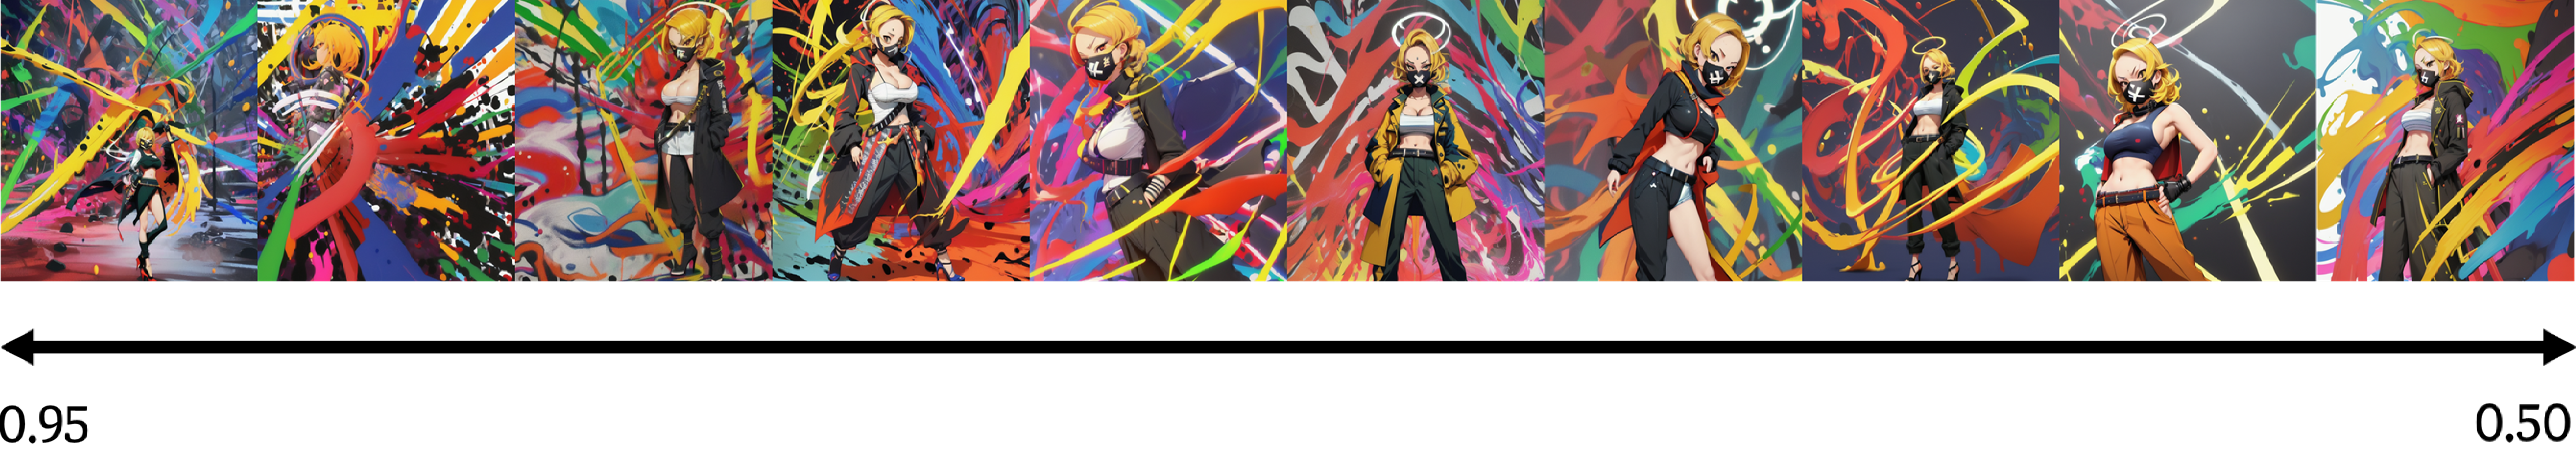

In [36]:
pipeline = StableDiffusionPipeline.from_pretrained("digiplay/hellofantasytime_v1.22", torch_dtype=torch.float16, requires_safety_checker=False, safety_checker=None)   # 알맞은 모델 ID 를 입력합니다.
pipeline.scheduler = DPMSolverMultistepScheduler.from_config(pipeline.scheduler.config)
pipeline.to("cuda")

pipeline.load_lora_weights(LORA_PATH_3)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.


In [37]:
# 같은 prompt로 lora 1개만 사용했을 경우
image = pipeline(
    prompt="standing, hands in pockets, 1girl, sukebanmg, blonde hair, forehead, halo, large breasts, black coat, bandolier, sarashi, belt, baggy pants, high heels,  p0ll0ck, colorful explosion, colorful explosion backgound (red, blue, green), ((full body, detail body)),",
    negative_prompt="(((pubic))), ((((pubic_hair)))),sketch, duplicate, NSFW, ugly, text, logo, monochrome, worst face, (bad and mutated hands:1.3), (worst quality:2.0), (low quality:2.0), (blurry:2.0), horror, geometry, (bad hands), (missing fingers), multiple limbs, bad anatomy, (interlocked fingers:1.2), Ugly Fingers, (extra digit and hands and fingers and legs and arms:1.4), crown braid, ((2girl)), (deformed fingers:1.2), (worst quality, low quality:1.2), chibi, (long fingers:1.2)",
    num_inference_steps=100,
    guidance_scale=7,
    generator=generator,
    cross_attention_kwargs={"scale": 0.8}
).images[0]

image.save("img/sd_lora_sample_5.png")

  0%|          | 0/100 [00:00<?, ?it/s]

<img src="/GoingDeeper/GoingDeeper09/img/sd_lora_sample_5.png" width="768px" height="768px"></img>

Image generation은 주어진 text, image 등에 따라 모델이 새로운 이미지를 합성하여, 기존 데이터와 통계적으로 일관되지만 관측되지 않았던 시각 패턴을 만들어내는 task입니다. 이러한 image generation은 콘텐츠/디자인 생성, personalized image/marketing, data augmentatio/ synthetic data, 복원/편집/변환 등 여러 분야에서 활용될 수 있습니다. 대표적인 기술로는 ViT, Diffusion, GAN 등이 있습니다.

본 실험에서는 diffusion 모델과 diffusion 모델에 적용될 수 있는 기술들을 활용하여 표현에 어떤 영향을 미치는지 확인해보겠습니다.

# 결과

- Image generation

기본적인 image generation 에서는 자연어 입력에 대해서 좋은 이미지를 생성해 냅니다.


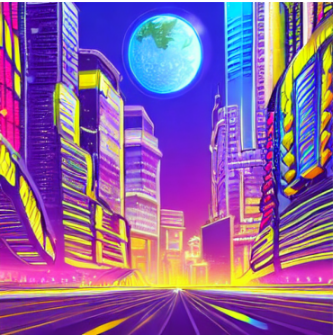

"A futuristic cityscape, vibrant and detailed. (not noisy image, clear image, masterpiece, high quality image)"

위의 생성된 이미지에서 사용된 prompt에서는 노이즈가 많이 섞이거나 화질이 좋지 않은 이미지를 생성하지 않기 위해서 clear image, masterpiece와 같이 이미지의 품질을 높여주는 prompt를 사용하였습니다.

- Text Prompt Interpolation

prompt를 latent space에서 보간하여 특정 비율로 섞인 서로 다른 prompt에서 생성되는 이미지를 정렬하면 prompt 보간에 따른 image 생성의 변화를 볼 수 있습니다. 추가적으로 아래와 같이 실험 시 기존의 prompt로는 낮은 품질, 심지어는 noise에 가까운 이미지가 생성되는 것을 확인할 수 있었습니다.

prompt_1 = "A watercolor painting of a Golden Retriever at the beach"

prompt_2 = "A still life DSLR photo of a bowl of fruit"

prompt_3 = "The eiffel tower in the style of starry night"

prompt_4 = "An architectural sketch of a skyscraper"

<img src="/GoingDeeper/GoingDeeper09/img/4-way-interpolation_with_safety_checker_allow_low_quality.jpg" width="768px" height="768px"></img>

또한 검은 부분은 safety_chacker에서 너무 폭력적이거나 선정적인 이미지를 검은 이미지로 생성해 냈기 때문으로 많은 부분의 이미지가 손실되어 있는것을 확인할 수 있습니다. 또한, prompt4의 경우 생성되는 이미지가 noise에 가깝습니다. 이러한 이미지들로는 prompt의 보간으로인한 image의 변화를 보기 힘들기 때문에 prompt에서 이전에 사용했던 화질을 높여주는 prompt를 사용하여 생성하면 다음과 같이 좋은 이미지를 얻을 수 있습니다.

prompt_1 = "A watercolor painting of a Golden Retriever at the beach. (not noisy image, clear image, masterpiece, high quality image)"

prompt_2 = "A still life DSLR photo of a bowl of fruit. (not noisy image, clear image, masterpiece, high quality image)"

prompt_3 = "The eiffel tower in the style of starry night. (not noisy image, clear image, masterpiece, high quality image)"

prompt_4 = "An architectural sketch of a skyscraper. (not noisy image, clear image, masterpiece, high quality image)"

<img src="/GoingDeeper/GoingDeeper09/img/4-way-interpolation_with_safety_checker.jpg" width="768px" height="768px"></img>

위의 이미지에서 나타났다 싶이 이전과 비교해서 더 좋은 품질의 이미지들을 생성하였습니다. propt4에 해당하는 이미지는 이전과 다르게 알아볼 수 있을 정도로 매우 많이 개선되었고, 다른 이미지들도 noise가 많이 없어져 품질이 개선되었습니다. 하지만 여전히 safety_chacker로 인하여 검은 이미지가 나타나고 있습니다. 따라서, 같은 prompt를 사용하여 safety_chacker를 None으로 할당 한 후 생성하면 다음과 같은 이미지를 얻을 수 있습니다.

<img src="/GoingDeeper/GoingDeeper09/img/4-way-interpolation.jpg" width="768px" height="768px"></img>

이미지에서 보이는 것과 같이 prompt4에 가까워지면 가까워 질 수록 색이 흑백으로 표현되는것을 알 수 있습니다. 또한, prompt로 생성되는 이미지의 특성이 prompt4는 흑백으로 특정되는 만큼 흑백으로 생성된 이미지를 보면 prompt4의 강도가 조절하지 않았음에도 상당히 강하다는 것을 확인할 수 있습니다. Prompt2에 까까울 수록 중앙의 객체가 존재하려고 하며 prompt3에 가까울 수록 둥근 물체들이 한 이미지에 표현되려고 합니다.

각 batch 마다 noise를 새로 생성하게 하여 더 다양한 결과를 얻을 수 도 있었습니다. 결과는 다음과 같습니다.

<img src="/GoingDeeper/GoingDeeper09/img/4-way-interpolation-varying-noise.jpg" width="768px" height="768px"></img>


다음은, 이미지를 생성할 때 고정된 방향으로 점점 encodeing vector를 추가해 볼수 있습니다. 이를 통하여 이미지가 step 별로 더해지는 vector 로 부터 어떤 이미지를 생성하는지 추정할 수 있습니다. 결과는 다음과 같습니다.

<img src="/GoingDeeper/GoingDeeper09/img/eiffel-tower-starry-night.gif" width="768px" height="768px"></img>

"The Eiffel Tower in the style of starry night. (not noisy image, clear image, masterpiece, high quality image)"

위의 이미지처럼 에펠탑이 점점 이미지에 noise가 높은 이미지로 변하는 것을 확인할 수 있습니다. 이미지를 확인해 보면 적절한 noise는 추가되는 것이 더 감각적인 이미지를 생성해 낼 수 있음을 알 수 있습니다. 이후, 마지막 부분에서 원본 이미지와 비슷하게 delta가 많이 추가되었음에도 불구하고 좋은 에펠탑 이미지가 생성되는 것을 확인하였지만 정확한 이유는 알 수 없어 해당 부분에 대하여 추가적인 실험이 필요합니다.


다음과 같이 소 이미지를 noise에 대하여 sin과 cos을 사용해 끝과 처음이 이어지게 만들어 개속 반복되는 이미지 처럼 생성할 수 도 있습니다. noise가 고정되고 random seed가 고정되어 있기 때문에 가능합니다.

<img src="/GoingDeeper/GoingDeeper09/img/cows.gif" width="768px" height="768px"></img>

"An oil paintings of detailed cows in a field next to a windmill in Holland. (not noisy image, clear image, masterpiece, high quality image)"

- DreamBooth

DreamBooth는 모델을 fine tunning하는 기법으로 기존의 학습 내용을 잊지 않으면서 새로운 내용을 학습하는 기법입니다. 모델의 모든 파라미터를 Fine-tuning 에 참여시키지 않고 여러 경로를 통해 모델의 일부분만 가지고 우리가 주입하고 싶은 데이터 학습 시키는 원리입니다. DreamBooth는 적은 양의 이미지로 좋은 학습 효과를 보여줍니다. DreamBooth로 강아지 이미지를 학습 시킨 후 이미지를 생성하면 다음과 같습니다.

<img src="/GoingDeeper/GoingDeeper09/img/dog-bucket.png" width="768px" height="768px"></img>

"A photo of sks dog chasing a car. (not noisy image, clear image, masterpiece, high quality image)"


- LoRA

LoRA는 over-parameter model 내부에서 본질적인 의미를 담고 있는 파라미터의 rank가 낮음으로, 대규모 모델의 파라미터를 저차원 공간으로 투영하는 방식을 활용하여 학습 시 pretrained model의 initialized weight는 동결시켜 가중치 업데이트를 하지 않고, 길이 r만큼의 low rank를 형성하는 행렬을 업데이트 합니다. 여러 LoRA에 대하여 결과를 확인해 보면 다음과 같습니다.

1. Style 1 LoRA

<img src="/GoingDeeper/GoingDeeper09/img/sd_lora_sample_1.png" width="768px" height="768px"></img>

prompt: "masterpiece, best quality, high quality, collage,<lora:collage-art-style-v03>,rainbow,"

negative_prompt: "(((pubic))), ((((pubic_hair)))),sketch, duplicate, ugly,text, logo, monochrome, (worst quality:2.0), (low quality:2.0), (blurry:2.0), horror, geometry, (bad hands), (missing fingers), multiple limbs, bad anatomy, (interlocked fingers:1.2), Ugly Fingers, (extra digit and hands and fingers and legs and arms:1.4), (deformed fingers:1.2), (long fingers:1.2)"
    

2. Style 2 LoRA

<img src="/GoingDeeper/GoingDeeper09/img/sd_lora_sample_2.png" width="768px" height="768px"></img>

prompt: "masterpiece, clear image, best quality, high quality, ultradetailed, drawing of a beautiful girl, ((ultradetailed eye)), p0ll0ck, colorful explosion, ((full body, detail body)), 1girl, modern clothes"

negative_prompt: "(((pubic))), ((((pubic_hair)))),sketch, duplicate, ugly, large head, low quality, extra digits, bad eye, huge eyes, text, logo, monochrome, worst face, (bad and mutated hands:1.3), (worst quality:2.0), (low quality:2.0), (blurry:2.0), horror, geometry, (bad hands), (missing fingers), multiple limbs, bad anatomy, (interlocked fingers:1.2), Ugly Fingers, (extra digit and hands and fingers and legs and arms:1.4), ((2girl)), (deformed fingers:1.2), (long fingers:1.2)"
    

3. character LoRA

<img src="/GoingDeeper/GoingDeeper09/img/sd_lora_sample_3.png" width="768px" height="768px"></img>

prompt: "simple background, standing, hands in pockets, looking at viewer, 1girl, <lora:Char - Blue Archive - Sukeban (MG) v2:0.8>, sukebanmg, yellow eyes, blonde hair, forehead, halo, large breasts, black coat, bandolier, sarashi, belt, baggy pants, high heels"

negative_prompt: "(((pubic))), ((((pubic_hair)))),sketch, duplicate, ugly, text, logo, monochrome, worst face, (bad and mutated hands:1.3), (worst quality:2.0), (low quality:2.0), (blurry:2.0), horror, geometry, (bad hands), (missing fingers), multiple limbs, bad anatomy, (interlocked fingers:1.2), Ugly Fingers, (extra digit and hands and fingers and legs and arms:1.4), crown braid, ((2girl)), (deformed fingers:1.2), (worst quality, low quality:1.2), chibi, (long fingers:1.2)"
    